# Fase 1 — Fundamentos de Deep Learning

## Objetivo

Cobrir os fundamentos que sustentam tudo que vem depois: perceptron, MLP, forward pass,
backpropagation, funções de ativação e de perda, gradiente descendente (SGD, Adam),
regularização (L2, Dropout, BatchNorm) e uma introdução a features tabulares com a API
`tf.estimator`.

Material adaptado de um curso próprio de TensorFlow já concluído
(`/dados/ML_and_DS/deep-learning-tensorflow`, `Part_3_redes_neurais_artificiais`).
Identificadores e comentários de código em inglês (padrão do projeto); explicações em
português.

Seções:

1. Perceptron simples (porta OR)
2. MLP com backpropagation (XOR)
3. MLP multiclasse (Iris) com Adam e mini-batches
4. Regularização: L2, Dropout e BatchNorm
5. Features tabulares com `tf.estimator.DNNClassifier` (census)
6. Features tabulares com `tf.estimator.DNNRegressor` (house prices)


## 1. Perceptron simples (porta OR)

Um único neurônio com ativação em degrau (*step function*) e regra delta aplicada
manualmente. Não há camada oculta: serve para mostrar a mecânica mínima de forward pass
e atualização de pesos antes de introduzir `GradientTape` e otimizadores prontos.


In [ ]:
import numpy as np
import tensorflow as tf

tf.__version__

2026-07-30 21:22:03.175697: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-30 21:22:03.175770: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-30 21:22:03.177226: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-30 21:22:03.185834: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


/home/lucas/.local/lib/python3.10/site-packages/google/api_core/_python_version_support.py:255: FutureWarning: You are using a Python version (3.10.12) which Google will stop supporting in new releases of google.api_core once it reaches its end of life (2026-10-04). Please upgrade to the latest Python version, or at least Python 3.11, to continue receiving updates for google.api_core past that date.
  warnings.warn(message, FutureWarning)


2026-07-30 21:22:05.182191: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT


'2.15.0'

In [2]:
# OR gate truth table
X = np.array([[0.0, 0.0],
              [0.0, 1.0],
              [1.0, 0.0],
              [1.0, 1.0]])

y = np.array([[0.0], [1.0], [1.0], [1.0]])

W = tf.Variable(tf.zeros([2, 1], dtype=tf.float64))
W


<tf.Variable 'Variable:0' shape=(2, 1) dtype=float64, numpy=
array([[0.],
       [0.]])>

In [3]:
def step(x):
    return tf.cast(tf.math.greater_equal(x, 1), tf.float64)


No TensorFlow 2.x não existe sessão: cada operação roda imediatamente (*eager execution*).
O treinamento abaixo atualiza `W` diretamente a cada época, sem `GradientTape` — a regra
delta é aplicada manualmente.

In [4]:
learning_rate = 1.0

for epoch in range(15):
    # Forward pass
    output_layer = tf.matmul(X, W)
    output_activation = step(output_layer)

    # Manual weight update (delta rule)
    error = tf.subtract(y, output_activation)
    delta = tf.matmul(X, error, transpose_a=True)
    W.assign_add(tf.multiply(delta, learning_rate))

W.numpy()


array([[2.],
       [2.]])

In [5]:
# Test
test_output = tf.matmul(X, W)
test_activation = step(test_output)
test_activation.numpy()


array([[0.],
       [1.],
       [1.],
       [1.]])

## 2. MLP com backpropagation (XOR)

A porta XOR não é linearmente separável — precisa de uma camada oculta. Aqui o forward
pass e o cálculo de gradientes usam `tf.GradientTape` (diferenciação automática) e o
otimizador `SGD` do Keras, em vez de uma regra de atualização manual.

In [6]:
import numpy as np
import tensorflow as tf

tf.random.set_seed(42)

X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([[0], [1], [1], [0]])

X = tf.convert_to_tensor(X, dtype=tf.float32, name='X')
y = tf.convert_to_tensor(y, dtype=tf.float32, name='y')


In [7]:
input_neurons = 2
hidden_neurons = 3
output_neurons = 1

W = {
    'hidden': tf.Variable(tf.random.normal([input_neurons, hidden_neurons]), name='w_hidden'),
    'output': tf.Variable(tf.random.normal([hidden_neurons, output_neurons]), name='w_output'),
}

b = {
    'hidden': tf.Variable(tf.random.normal([hidden_neurons]), name='b_hidden'),
    'output': tf.Variable(tf.random.normal([output_neurons]), name='b_output'),
}


Desde o TensorFlow 2, os otimizadores que ficavam em `tf.train` passaram para
`tf.keras.optimizers`, e as funções de perda para `tf.keras.losses` /
`tf.nn`. Todas as operações que compõem o forward pass até o cálculo do erro precisam
estar dentro do bloco `tf.GradientTape()` para que os gradientes sejam registrados.

In [8]:
def mlp_forward(x):
    hidden_layer = tf.add(tf.matmul(x, W['hidden']), b['hidden'])
    hidden_activation = tf.sigmoid(hidden_layer)
    output_layer = tf.add(tf.matmul(hidden_activation, W['output']), b['output'])
    return tf.sigmoid(output_layer)


var_list = [W['hidden'], W['output'], b['hidden'], b['output']]
optimizer = tf.keras.optimizers.SGD(learning_rate=0.3)

for epoch in range(10000):
    with tf.GradientTape() as tape:
        output_activation = mlp_forward(X)
        error = tf.reduce_mean(tf.square(tf.subtract(y, output_activation)))
    gradients = tape.gradient(error, var_list)
    optimizer.apply_gradients(zip(gradients, var_list))

    if epoch % 2000 == 0:
        print(f'epoch {epoch:5d}  mse={error.numpy():.4f}')


epoch     0  mse=0.2859


epoch  2000  mse=0.0918


epoch  4000  mse=0.0070


epoch  6000  mse=0.0031


epoch  8000  mse=0.0019


In [9]:
# Test
mlp_forward(X).numpy()


array([[0.017884  ],
       [0.9585594 ],
       [0.9650456 ],
       [0.04636087]], dtype=float32)

## 3. MLP multiclasse (Iris) com Adam e mini-batches

Exemplo completo de classificação multiclasse: padronização de entrada, one-hot da
saída, MLP com ReLU na camada oculta, perda `softmax_cross_entropy`, otimizador Adam e
treinamento em mini-batches via `tf.data.Dataset`.

In [10]:
import numpy as np
import tensorflow as tf
from sklearn import datasets
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

tf.random.set_seed(42)

iris = datasets.load_iris()
X = iris.data
y = iris.target.reshape(-1, 1)

X = StandardScaler().fit_transform(X)
y = OneHotEncoder().fit_transform(y).toarray()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape


((105, 4), (45, 4))

In [11]:
input_neurons = X.shape[1]
hidden_neurons = int(np.ceil((X.shape[1] + y.shape[1]) / 2))
output_neurons = y.shape[1]

W = {
    'hidden': tf.Variable(tf.random.normal([input_neurons, hidden_neurons])),
    'output': tf.Variable(tf.random.normal([hidden_neurons, output_neurons])),
}
b = {
    'hidden': tf.Variable(tf.random.normal([hidden_neurons])),
    'output': tf.Variable(tf.random.normal([output_neurons])),
}

X_train = tf.convert_to_tensor(X_train, dtype=tf.float32)
y_train = tf.convert_to_tensor(y_train, dtype=tf.float32)
X_test = tf.convert_to_tensor(X_test, dtype=tf.float32)
y_test = tf.convert_to_tensor(y_test, dtype=tf.float32)


In [12]:
def mlp(x, weights, bias):
    hidden_layer = tf.add(tf.matmul(x, weights['hidden']), bias['hidden'])
    hidden_activation = tf.nn.relu(hidden_layer)
    output_layer = tf.add(tf.matmul(hidden_activation, weights['output']), bias['output'])
    return output_layer


var_list = [W['hidden'], W['output'], b['hidden'], b['output']]
optimizer = tf.keras.optimizers.Adam(learning_rate=0.01)

batch_size = 8
dataset = tf.data.Dataset.from_tensor_slices((X_train, y_train)).batch(batch_size)

for epoch in range(300):
    for X_batch, y_batch in dataset:
        with tf.GradientTape() as tape:
            logits = mlp(X_batch, W, b)
            loss = tf.reduce_mean(
                tf.nn.softmax_cross_entropy_with_logits(labels=y_batch, logits=logits)
            )
        gradients = tape.gradient(loss, var_list)
        optimizer.apply_gradients(zip(gradients, var_list))

    if epoch % 50 == 0:
        print(f'epoch {epoch:4d}  loss={loss.numpy():.4f}')


epoch    0  loss=0.7202


epoch   50  loss=0.0020


epoch  100  loss=0.0004


epoch  150  loss=0.0001


epoch  200  loss=0.0001


epoch  250  loss=0.0000


In [13]:
test_logits = mlp(X_test, W, b)
test_predictions = tf.argmax(tf.nn.softmax(test_logits), axis=1).numpy()
test_labels = tf.argmax(y_test, axis=1).numpy()

accuracy = accuracy_score(test_labels, test_predictions)
accuracy


1.0

## 4. Regularização: L2, Dropout e BatchNorm

Nenhum notebook do curso original cobre regularização explicitamente — esta seção é
material novo, escrito para fechar essa lacuna. Reaproveita o dataset Iris já preparado
acima, agora usando a API `tf.keras.Sequential` (mais direta para empilhar
`Dense` + `BatchNormalization` + `Dropout`).

Ideia central: `BatchNormalization` estabiliza a distribuição das ativações entre
camadas, `Dropout` desliga neurônios aleatoriamente durante o treino para reduzir
coadaptação, e a penalização L2 (`kernel_regularizer`) desincentiva pesos grandes.


In [14]:
from tensorflow.keras import layers, regularizers

l2_penalty = 1e-3
dropout_rate = 0.3

regularized_model = tf.keras.Sequential([
    layers.Input(shape=(input_neurons,)),
    layers.Dense(hidden_neurons, kernel_regularizer=regularizers.l2(l2_penalty)),
    layers.BatchNormalization(),
    layers.Activation('relu'),
    layers.Dropout(dropout_rate),
    layers.Dense(output_neurons, activation='softmax'),
])

regularized_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
    loss='categorical_crossentropy',
    metrics=['accuracy'],
)

regularized_model.summary()


Model: "sequential"


_________________________________________________________________


 Layer (type)                Output Shape              Param #   


 dense (Dense)               (None, 4)                 20        


 batch_normalization (Batch  (None, 4)                 16        


...

 dense_1 (Dense)             (None, 3)                 15        


Total params: 51 (204.00 Byte)


Trainable params: 43 (172.00 Byte)


Non-trainable params: 8 (32.00 Byte)


_________________________________________________________________


In [15]:
history = regularized_model.fit(
    X_train, y_train,
    validation_data=(X_test, y_test),
    epochs=100,
    batch_size=8,
    verbose=0,
)

test_loss, test_accuracy = regularized_model.evaluate(X_test, y_test, verbose=0)
print(f'test loss={test_loss:.4f}  test accuracy={test_accuracy:.4f}')


test loss=0.2782  test accuracy=0.8889


In [ ]:
import pandas as pd
from pathlib import Path

# Save training history so the figure script (tex/figures/make_ch01_figures.py)
# can plot it without repeating the training run.
history_df = pd.DataFrame(history.history)
history_df.insert(0, 'epoch', range(1, len(history_df) + 1))

PROJECT_ROOT = Path.cwd().resolve().parents[2]
processed_dir = PROJECT_ROOT / 'data' / 'processed'
processed_dir.mkdir(parents=True, exist_ok=True)

history_path = processed_dir / 'deep_learning_regularization_history.csv'
history_df.to_csv(history_path, index=False)
print(f'Saved training history to: {history_path}')


/home/lucas/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


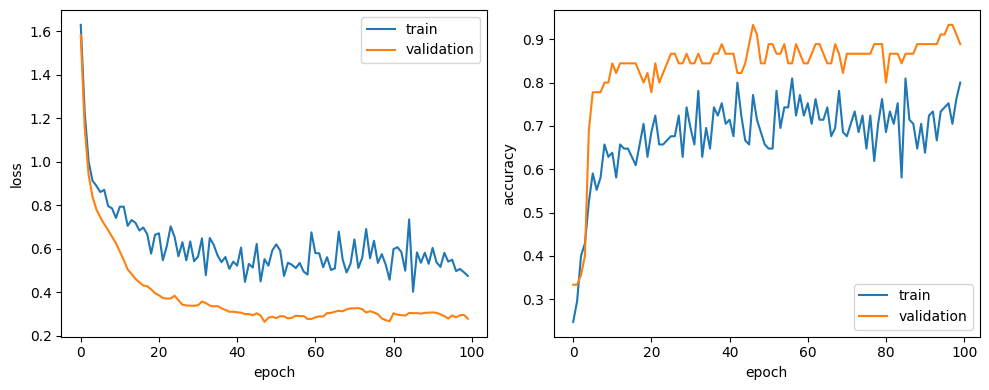

In [16]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(10, 4))

axes[0].plot(history.history['loss'], label='train')
axes[0].plot(history.history['val_loss'], label='validation')
axes[0].set_xlabel('epoch')
axes[0].set_ylabel('loss')
axes[0].legend()

axes[1].plot(history.history['accuracy'], label='train')
axes[1].plot(history.history['val_accuracy'], label='validation')
axes[1].set_xlabel('epoch')
axes[1].set_ylabel('accuracy')
axes[1].legend()

fig.tight_layout()


Nota: este gráfico é exploratório, para acompanhar o treino dentro do notebook — não é
a figura final de publicação. Figuras destinadas ao `tex/` seguem o pipeline separado de
cálculo/dado/figura descrito em `ai/policies/POLICIES_code-figures-data.md`.

## 5. Features tabulares com `tf.estimator.DNNClassifier` (census)

Exemplo de rede neural para dados tabulares mistos (categóricos + numéricos) usando a
API `tf.estimator`. É uma API legada — descontinuada em favor do Keras — mas ainda
funciona no TensorFlow 2.15 usado aqui, e ilustra `feature_column`s: colunas
categóricas por hash bucket, colunas de vocabulário fixo, embeddings e normalização via
`normalizer_fn`.

Dataset: `data/raw/census.csv` (renda anual acima/abaixo de USD 50k a partir de dados
demográficos). Ver origem em `data/manifests/deep_learning_phase1_sources.md`.


In [17]:
from pathlib import Path
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split

# Assumes the notebook is run from its own directory (contents/deep_learning/)
PROJECT_ROOT = Path.cwd().resolve().parents[2]
census_path = PROJECT_ROOT / 'data' / 'raw' / 'census.csv'

data = pd.read_csv(census_path)
data.income = data.income.apply(lambda label: 1 if label == ' >50K' else 0)

X = data.drop('income', axis=1)
y = data.income

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape


((22792, 14), (9769, 14))

In [18]:
workclass = tf.feature_column.categorical_column_with_hash_bucket('workclass', hash_bucket_size=100)
education = tf.feature_column.categorical_column_with_hash_bucket('education', hash_bucket_size=100)
marital_status = tf.feature_column.categorical_column_with_hash_bucket('marital-status', hash_bucket_size=100)
occupation = tf.feature_column.categorical_column_with_hash_bucket('occupation', hash_bucket_size=100)
relationship = tf.feature_column.categorical_column_with_hash_bucket('relationship', hash_bucket_size=100)
race = tf.feature_column.categorical_column_with_hash_bucket('race', hash_bucket_size=100)
country = tf.feature_column.categorical_column_with_hash_bucket('native-country', hash_bucket_size=100)

sex = tf.feature_column.categorical_column_with_vocabulary_list('sex', vocabulary_list=[' Male', ' Female'])


Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


In [19]:
# Note: 'capital-loos' and 'hour-per-week' are the actual (misspelled) column
# names in this dataset — kept as-is to match data/raw/census.csv.
age_mean, age_std = data.age.mean(), data.age.std()
weight_mean, weight_std = data['final-weight'].mean(), data['final-weight'].std()
education_num_mean, education_num_std = data['education-num'].mean(), data['education-num'].std()
capital_gain_mean, capital_gain_std = data['capital-gain'].mean(), data['capital-gain'].std()
capital_loss_mean, capital_loss_std = data['capital-loos'].mean(), data['capital-loos'].std()
hours_mean, hours_std = data['hour-per-week'].mean(), data['hour-per-week'].std()


def standardize(mean, std):
    def normalizer(value):
        return tf.divide(tf.subtract(tf.cast(value, tf.float32), tf.constant(float(mean))),
                          tf.constant(float(std)))
    return normalizer


age = tf.feature_column.numeric_column('age', normalizer_fn=standardize(age_mean, age_std))
final_weight = tf.feature_column.numeric_column('final-weight', normalizer_fn=standardize(weight_mean, weight_std))
education_num = tf.feature_column.numeric_column('education-num', normalizer_fn=standardize(education_num_mean, education_num_std))
capital_gain = tf.feature_column.numeric_column('capital-gain', normalizer_fn=standardize(capital_gain_mean, capital_gain_std))
capital_loss = tf.feature_column.numeric_column('capital-loos', normalizer_fn=standardize(capital_loss_mean, capital_loss_std))
hours_per_week = tf.feature_column.numeric_column('hour-per-week', normalizer_fn=standardize(hours_mean, hours_std))


Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


In [20]:
embedded_workclass = tf.feature_column.embedding_column(workclass, dimension=9)
embedded_education = tf.feature_column.embedding_column(education, dimension=len(data.education.unique()))
embedded_marital = tf.feature_column.embedding_column(marital_status, dimension=len(data['marital-status'].unique()))
embedded_occupation = tf.feature_column.embedding_column(occupation, dimension=len(data.occupation.unique()))
embedded_relationship = tf.feature_column.embedding_column(relationship, dimension=len(data.relationship.unique()))
embedded_race = tf.feature_column.embedding_column(race, dimension=len(data.race.unique()))
embedded_sex = tf.feature_column.embedding_column(sex, dimension=len(data.sex.unique()))
embedded_country = tf.feature_column.embedding_column(country, dimension=len(data['native-country'].unique()))

feature_columns = [
    age, embedded_workclass, final_weight, embedded_education, education_num,
    embedded_marital, embedded_occupation, embedded_relationship,
    embedded_race, embedded_sex,
    capital_gain, capital_loss, hours_per_week, embedded_country,
]


Instructions for updating:
Use Keras preprocessing layers instead, either directly or via the `tf.keras.utils.FeatureSpace` utility. Each of `tf.feature_column.*` has a functional equivalent in `tf.keras.layers` for feature preprocessing when training a Keras model.


In [21]:
def make_input_fn(X, y=None, num_epochs=None, shuffle=True, batch_size=32):
    def input_fn():
        ds = tf.data.Dataset.from_tensor_slices((dict(X), y))
        if shuffle:
            ds = ds.shuffle(1000)
        return ds.batch(batch_size).repeat(num_epochs)
    return input_fn


train_fn = make_input_fn(X_train, y_train)
test_fn = make_input_fn(X_test, y_test, num_epochs=1, shuffle=False)

config = tf.estimator.RunConfig(tf_random_seed=42)
classifier = tf.estimator.DNNClassifier(
    hidden_units=[8, 8], feature_columns=feature_columns, n_classes=2, config=config,
)


Instructions for updating:
Use tf.keras instead.


Instructions for updating:
Use tf.keras instead.


Instructions for updating:
Use tf.keras instead.


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Using config: {'_model_dir': '/tmp/tmpapom4esy', '_tf_random_seed': 42, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


**Nota de execução**: benchmark rápido fora do notebook (500 passos) indicou ~11 ms/passo com as 14 colunas completas — os 10000 passos abaixo levam cerca de 2 minutos em CPU.

In [22]:
classifier.train(input_fn=train_fn, steps=10000)


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Calling model_fn.


Instructions for updating:
Call initializer instance with the dtype argument instead of passing it to the constructor


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Done calling model_fn.


...

INFO:tensorflow:loss = 0.36601865, step = 9900 (0.098 sec)


INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 10000...


INFO:tensorflow:Saving checkpoints for 10000 into /tmp/tmpapom4esy/model.ckpt.


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 10000...


INFO:tensorflow:Loss for final step: 0.61470956.


In [23]:
classifier.evaluate(input_fn=test_fn)


INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Done calling model_fn.


INFO:tensorflow:Starting evaluation at 2026-07-30T21:25:17


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Graph was finalized.


...

INFO:tensorflow:Inference Time : 1.97679s


INFO:tensorflow:Finished evaluation at 2026-07-30-21:25:19


INFO:tensorflow:Saving dict for global step 10000: accuracy = 0.8226021, accuracy_baseline = 0.7631283, auc = 0.86698675, auc_precision_recall = 0.65951115, average_loss = 0.38096642, global_step = 10000, label/mean = 0.23687173, loss = 0.38084257, precision = 0.6800992, prediction/mean = 0.24515742, recall = 0.47407088


INFO:tensorflow:Saving 'checkpoint_path' summary for global step 10000: /tmp/tmpapom4esy/model.ckpt-10000


{'accuracy': 0.8226021,
 'accuracy_baseline': 0.7631283,
 'auc': 0.86698675,
 'auc_precision_recall': 0.65951115,
 'average_loss': 0.38096642,
 'label/mean': 0.23687173,
 'loss': 0.38084257,
 'precision': 0.6800992,
 'prediction/mean': 0.24515742,
 'recall': 0.47407088,
 'global_step': 10000}

## 6. Features tabulares com `tf.estimator.DNNRegressor` (house prices)

Mesma API `tf.estimator`, agora para regressão. Todas as colunas usadas já são
numéricas, com escala `MinMaxScaler` para entradas e saída.

Dataset: `data/raw/house_prices.csv` (preços de imóveis, King County). Ver origem em
`data/manifests/deep_learning_phase1_sources.md`.


In [24]:
from pathlib import Path
import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error

PROJECT_ROOT = Path.cwd().resolve().parents[2]
house_prices_path = PROJECT_ROOT / 'data' / 'raw' / 'house_prices.csv'

columns_used = [
    'price', 'bedrooms', 'bathrooms', 'sqft_living', 'sqft_lot', 'floors',
    'waterfront', 'view', 'condition', 'grade', 'sqft_above', 'sqft_basement',
    'yr_built', 'yr_renovated', 'zipcode', 'lat', 'long',
]
data = pd.read_csv(house_prices_path, usecols=columns_used)

feature_names = columns_used[1:]

scaler_x = MinMaxScaler()
data[feature_names] = scaler_x.fit_transform(data[feature_names])

scaler_y = MinMaxScaler()
data[['price']] = scaler_y.fit_transform(data[['price']])

X = data.drop('price', axis=1)
y = data.price

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
X_train.shape, X_test.shape


((15129, 16), (6484, 16))

In [25]:
feature_columns = [tf.feature_column.numeric_column(name) for name in feature_names]


def make_input_fn(X, y=None, num_epochs=None, shuffle=True, batch_size=32):
    def input_fn():
        ds = tf.data.Dataset.from_tensor_slices((dict(X), y))
        if shuffle:
            ds = ds.shuffle(1000)
        return ds.batch(batch_size).repeat(num_epochs)
    return input_fn


train_fn = make_input_fn(X_train, y_train)
predict_fn = make_input_fn(X_test, num_epochs=1, shuffle=False)

config = tf.estimator.RunConfig(tf_random_seed=24)
regressor = tf.estimator.DNNRegressor(
    hidden_units=[8, 8, 8], feature_columns=feature_columns, config=config,
)


Instructions for updating:
Use tf.keras instead.


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Using config: {'_model_dir': '/tmp/tmph16gb1os', '_tf_random_seed': 24, '_save_summary_steps': 100, '_save_checkpoints_steps': None, '_save_checkpoints_secs': 600, '_session_config': allow_soft_placement: true
graph_options {
  rewrite_options {
    meta_optimizer_iterations: ONE
  }
}
, '_keep_checkpoint_max': 5, '_keep_checkpoint_every_n_hours': 10000, '_log_step_count_steps': 100, '_train_distribute': None, '_device_fn': None, '_protocol': None, '_eval_distribute': None, '_experimental_distribute': None, '_experimental_max_worker_delay_secs': None, '_session_creation_timeout_secs': 7200, '_checkpoint_save_graph_def': True, '_service': None, '_cluster_spec': ClusterSpec({}), '_task_type': 'worker', '_task_id': 0, '_global_id_in_cluster': 0, '_master': '', '_evaluation_master': '', '_is_chief': True, '_num_ps_replicas': 0, '_num_worker_replicas': 1}


**Nota de execução**: benchmark rápido (500 passos) indicou ~4 ms/passo — os 20000 passos abaixo levam cerca de 1-2 minutos em CPU.

In [26]:
regressor.train(input_fn=train_fn, steps=20000)


INFO:tensorflow:Calling model_fn.


INFO:tensorflow:Done calling model_fn.


INFO:tensorflow:Create CheckpointSaverHook.


INFO:tensorflow:Graph was finalized.


INFO:tensorflow:Running local_init_op.


...

INFO:tensorflow:loss = 0.0013247139, step = 19900 (0.070 sec)


INFO:tensorflow:Calling checkpoint listeners before saving checkpoint 20000...


INFO:tensorflow:Saving checkpoints for 20000 into /tmp/tmph16gb1os/model.ckpt.


INFO:tensorflow:Calling checkpoint listeners after saving checkpoint 20000...


INFO:tensorflow:Loss for final step: 0.0025132252.


In [27]:
predictions = np.array([p['predictions'][0] for p in regressor.predict(input_fn=predict_fn)])
predictions = scaler_y.inverse_transform(predictions.reshape(-1, 1))

y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

mae = mean_absolute_error(y_test_original, predictions)
mae


INFO:tensorflow:Calling model_fn.


Instructions for updating:
Use tf.keras instead.


Instructions for updating:
Use tf.keras instead.


INFO:tensorflow:Done calling model_fn.


INFO:tensorflow:Graph was finalized.


INFO:tensorflow:Restoring parameters from /tmp/tmph16gb1os/model.ckpt-20000


INFO:tensorflow:Running local_init_op.


INFO:tensorflow:Done running local_init_op.


199416.17107284517